# Titanic Survival Analysis 🚢

## Dataset Overview
- **Source:** Kaggle - Titanic Dataset
- **Rows:** 891 passengers
- **Columns:** 12 features including Age, Sex, Pclass, Survived

In [11]:
import pandas as pd
df= pd.read_csv(r"C:\Users\User\OneDrive\Desktop\vs code\task2\train.csv")
print(df.shape)
print(df.head())

(891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN    

## Data Cleaning
- **Age:** 177 missing values → filled with median age (29.0)
- **Cabin:** 687 missing values → dropped column entirely
- **Embarked:** 2 missing values → filled with most common port (S)

In [12]:
print(df.isnull().sum())
#Filling missing Age with median age
df['Age'] = df['Age'].fillna(df['Age'].median())

#Drop Cabin column - too many missing values to be useful
df = df.drop(columns=['Cabin'])

#Fill the 2 missing Embarked with the most common value
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


## Analysis & Findings

### 1. Survival by Gender

Female - 74.2%

Male - 18.9% 

**Insight:** Females survived at nearly 4x the rate of males.

In [13]:
survival_by_gender = df.groupby('Sex')['Survived'].mean() * 100
print("Survival rate by gender (%):")
print(survival_by_gender)

Survival rate by gender (%):
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


### 2. Survival by Passenger Class
| Class | Survival Rate |
|-------|--------------|
| 1st Class | 63.0% |
| 2nd Class | 47.3% |
| 3rd Class | 24.2% |

**Insight:** A 1st class passenger was 2.6x more likely to survive than
a 3rd class passenger. Wealthier passengers had better cabin proximity
to the deck and priority lifeboat access.





In [14]:
survival_by_class = df.groupby('Pclass')['Survived'].mean() * 100
print("\nSurvival rate by class (%):")
print(survival_by_class)



Survival rate by class (%):
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


### 3. Survival by Age Group
| Age Group | Survival Rate |
|-----------|--------------|
| Child (0-12) | 58.0% |
| Teen (12-18) | 42.9% |
| Young Adult (18-35) | 35.3% |
| Adult (35-60) | 40.0% |
| Senior (60+) | 22.7% |

**Insight:** Children had the highest survival rate, confirming
evacuation priority. Seniors had the lowest survival rate.


In [15]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100], 
                         labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])
survival_by_age = df.groupby('AgeGroup')['Survived'].mean() * 100
print("\nSurvival rate by age group (%):")
print(survival_by_age)


Survival rate by age group (%):
AgeGroup
Child          57.971014
Teen           42.857143
Young Adult    35.327103
Adult          40.000000
Senior         22.727273
Name: Survived, dtype: float64


## Visual Represntation

### 1.Bar chart of survival by gender.

A bar chart depicting the survival rate of passengers by gender on the titanic.

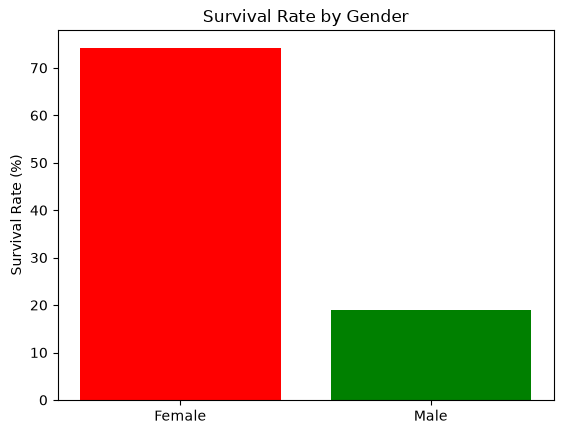

In [16]:
import matplotlib.pyplot as plt
#Survival by Gender
plt.bar(['Female', 'Male'], survival_by_gender.values, color=['red', 'green'])
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate (%)')
plt.show()

### 2. Bar chart of survival by class.

Showcasing the survival rate of passengers by class - 1st class, 2nd class , 3rd class.

1st Class | 63.0%

2nd Class | 47.3%

3rd Class | 24.2% 

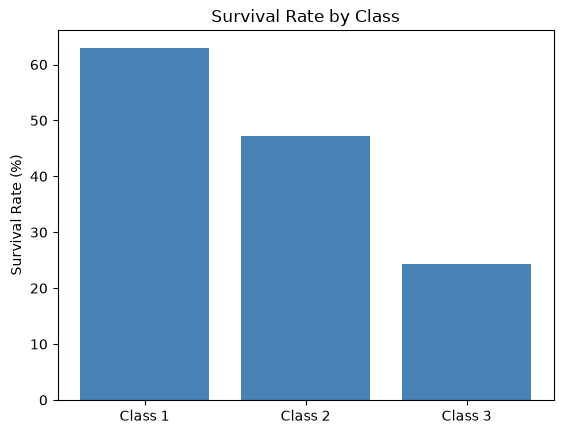

In [17]:
plt.bar(['Class 1', 'Class 2', 'Class 3'], survival_by_class.values, color='steelblue')
plt.title('Survival Rate by Class')
plt.ylabel('Survival Rate (%)')
plt.show()

### 3. Histogram of passenger ages.

A histogram depicting the different ages of passenger in the titanic.

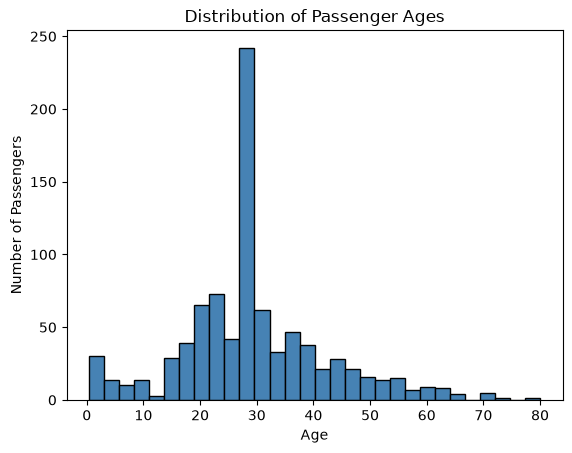

In [18]:
plt.hist(df['Age'], bins=30, color='steelblue', edgecolor='black')
plt.title('Distribution of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()

## Overall Conclusion

Survival on the Titanic was largely determined by factors outside
a passenger's control — gender and ticket class.

- A **3rd class male** had roughly a **15-18% chance** of survival
- A **1st class female** had close to a **95% chance** of survival

This highlights how systemic inequality had direct life-or-death consequences.

---